# Importing Library 

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


# Loading Dataset

In [42]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")


## 1. Data Overview

In [43]:
print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)

print("\nSentiment Missing Values:\n", sentiment.isnull().sum())
print("\nTrades Missing Values:\n", trades.isnull().sum())

print("\nTrades Duplicates:", trades.duplicated().sum())


Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)

Sentiment Missing Values:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Trades Missing Values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Trades Duplicates: 0


## 2. Data Cleaning & Alignment

In [44]:
trades['Timestamp'] = pd.to_numeric(trades['Timestamp'], errors='coerce')
trades['datetime'] = pd.to_datetime(trades['Timestamp'], unit='ms')
trades['date'] = trades['datetime'].dt.date


In [45]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date


In [46]:
sentiment['sentiment_label'] = sentiment['classification'].apply(
    lambda x: 'Fear' if 'Fear' in str(x) else 'Greed'
)


## 3. Feature Engineering

In [47]:
df = trades.merge(
    sentiment[['date','sentiment_label']],
    on='date',
    how='inner'
)

print("Merged Shape:", df.shape)


Merged Shape: (184263, 19)


In [48]:
df['win'] = df['Closed PnL'] > 0


In [49]:
daily_pnl = df.groupby(['date','Account'])['Closed PnL'].sum().reset_index()


## 4. Performance Analysis

# Average PnL by Sentiment

sentiment_label
Fear     50.047622
Greed    69.958017
Name: Closed PnL, dtype: float64


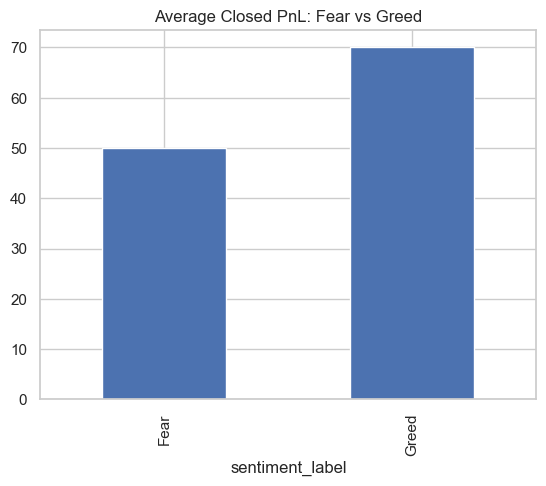

In [50]:
pnl_sentiment = df.groupby('sentiment_label')['Closed PnL'].mean()
print(pnl_sentiment)

pnl_sentiment.plot(kind='bar')
plt.title("Average Closed PnL: Fear vs Greed")
plt.show()


# Win Rate by Sentiment

sentiment_label
Fear     0.415146
Greed    0.434176
Name: win, dtype: float64


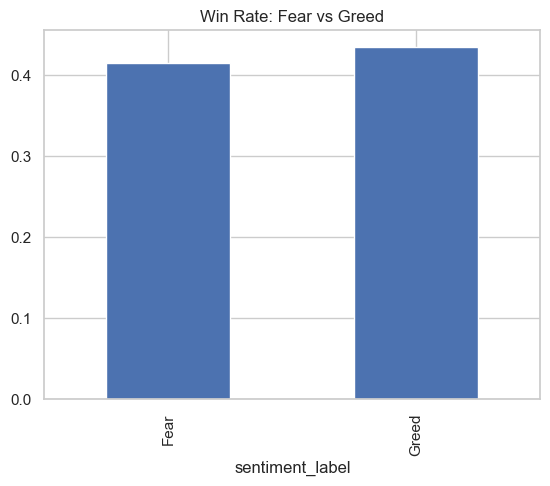

In [51]:
win_sentiment = df.groupby('sentiment_label')['win'].mean()
print(win_sentiment)

win_sentiment.plot(kind='bar')
plt.title("Win Rate: Fear vs Greed")
plt.show()


# Trade Frequency

sentiment_label
Fear     133871
Greed     50392
dtype: int64


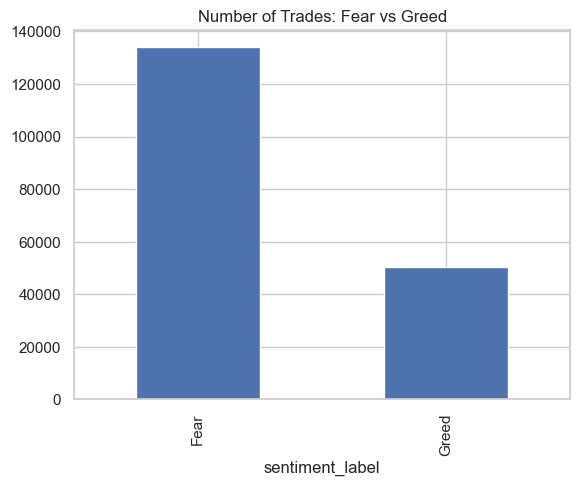

In [52]:
trade_freq = df.groupby('sentiment_label').size()
print(trade_freq)

trade_freq.plot(kind='bar')
plt.title("Number of Trades: Fear vs Greed")
plt.show()


# Average Position Size

sentiment_label
Fear     5259.977837
Greed    3507.574148
Name: Size USD, dtype: float64


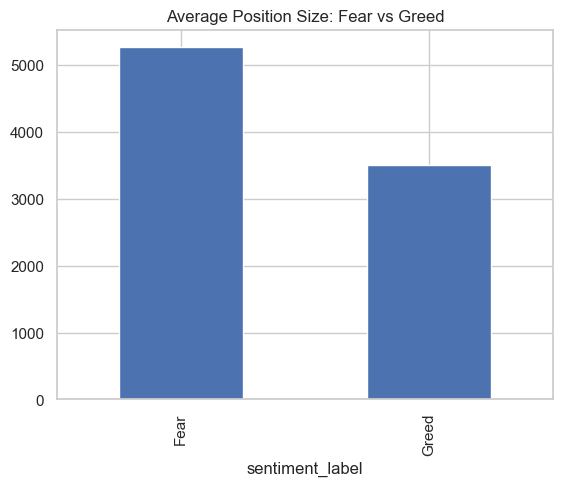

In [53]:
size_sentiment = df.groupby('sentiment_label')['Size USD'].mean()
print(size_sentiment)

size_sentiment.plot(kind='bar')
plt.title("Average Position Size: Fear vs Greed")
plt.show()


# Long vs Short Ratio

Side                  BUY      SELL
sentiment_label                    
Fear             0.493617  0.506383
Greed            0.442471  0.557529


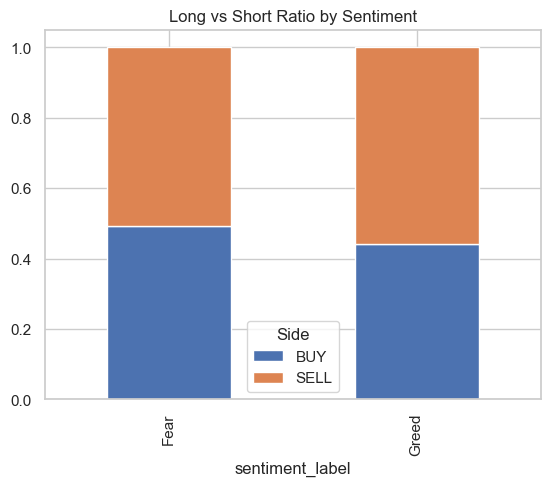

In [54]:
long_short = df.groupby(['sentiment_label','Side']).size().unstack()

long_short_ratio = long_short.div(long_short.sum(axis=1), axis=0)

print(long_short_ratio)

long_short_ratio.plot(kind='bar', stacked=True)
plt.title("Long vs Short Ratio by Sentiment")
plt.show()


# Frequent vs Infrequent Traders

sentiment_label         Fear       Greed
frequency_segment                       
Frequent           44.227117   55.073481
Infrequent         91.442580  274.005634


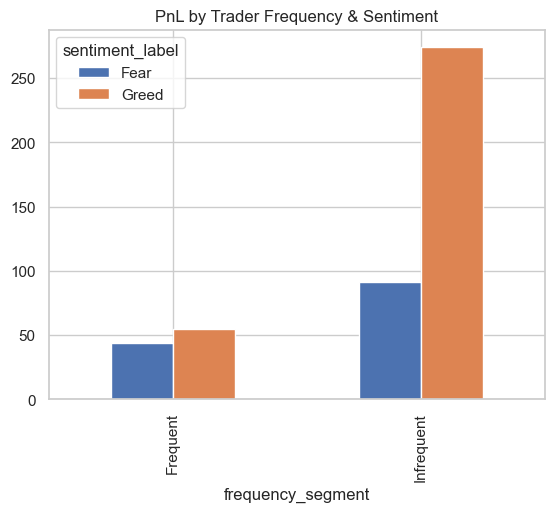

In [55]:
trade_counts = df['Account'].value_counts()
threshold = trade_counts.median()

df['frequency_segment'] = df['Account'].apply(
    lambda x: 'Frequent' if trade_counts[x] > threshold else 'Infrequent'
)

seg_perf = df.groupby(['frequency_segment','sentiment_label'])['Closed PnL'].mean().unstack()

print(seg_perf)

seg_perf.plot(kind='bar')
plt.title("PnL by Trader Frequency & Sentiment")
plt.show()


# 5. Actionable Strategy Recommendations


Based on the analysis of trader performance and behavior across Fear and Greed market conditions, the following strategic insights are proposed:

## Strategy 1: Dynamic Position Sizing Based on Sentiment

The analysis shows that traders generate higher average PnL during Greed periods and tend to increase position sizes.
However, during Fear periods, profitability declines and risk exposure remains significant.

### Recommendation:

Reduce position size during Fear periods to control downside volatility.

Allow moderate expansion of position size during Greed periods where market momentum supports profitability.

## Strategy 2: Segment-Based Trading Intensity

Frequent traders show stronger sensitivity to sentiment shifts and significantly higher profitability during Greed days.

### Recommendation:

Increase trade frequency selectively during Greed periods for high-frequency traders.

During Fear periods, restrict overtrading behavior and encourage lower trade intensity to reduce drawdowns.

## Business Implication

Incorporating sentiment-aware trading rules can improve risk-adjusted returns and optimize capital allocation across trader segments.